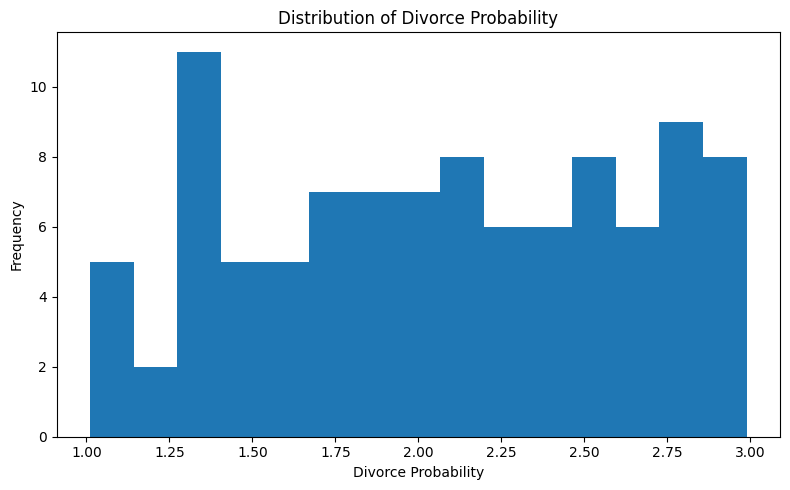

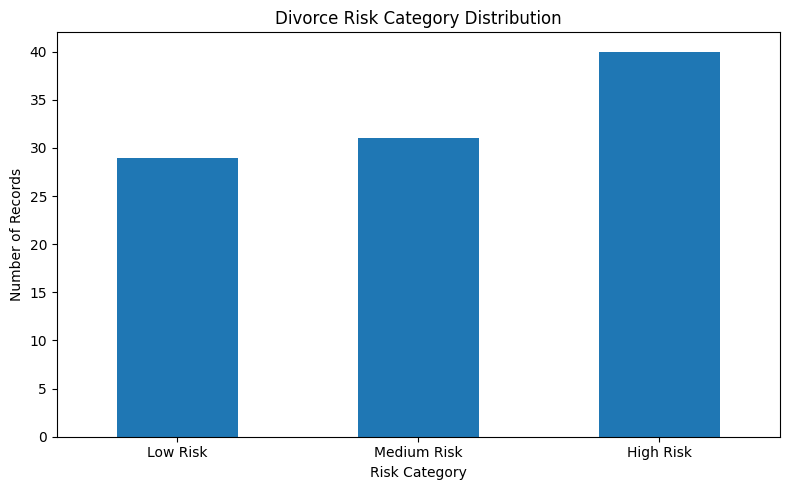

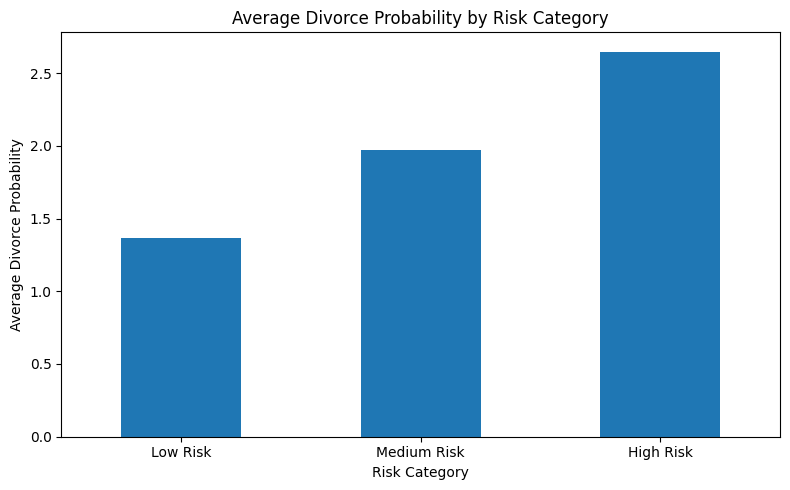

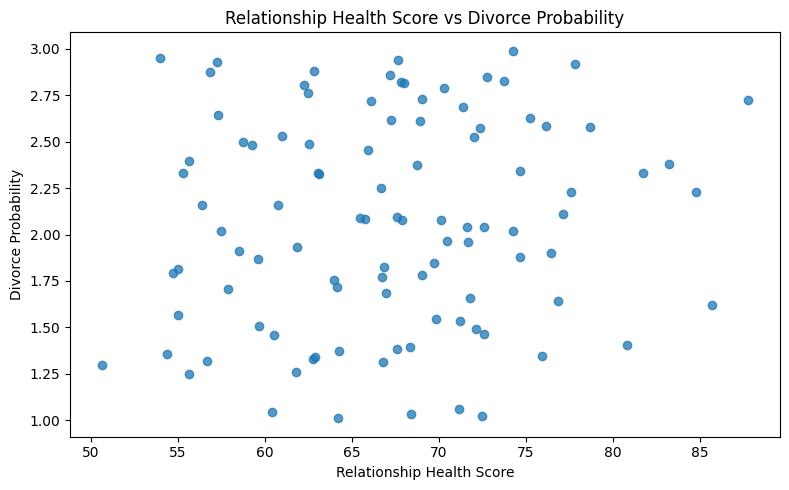

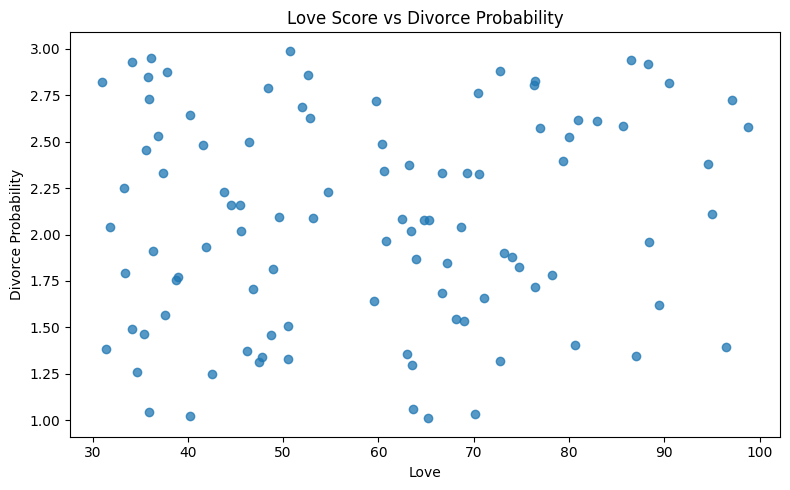

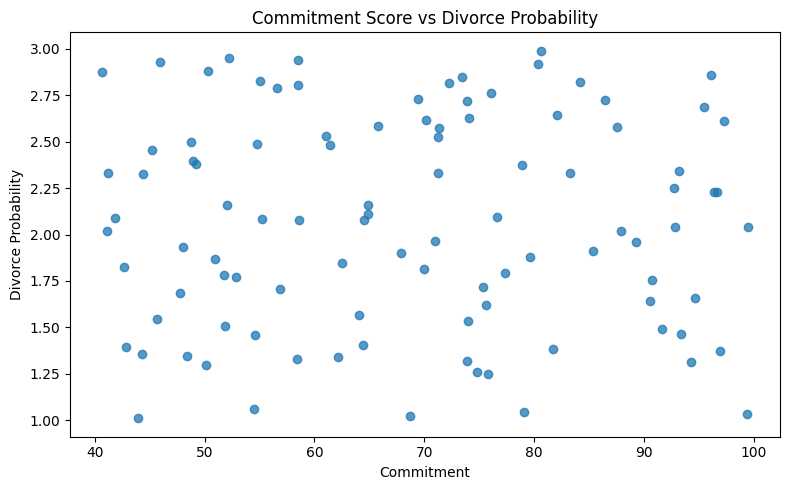

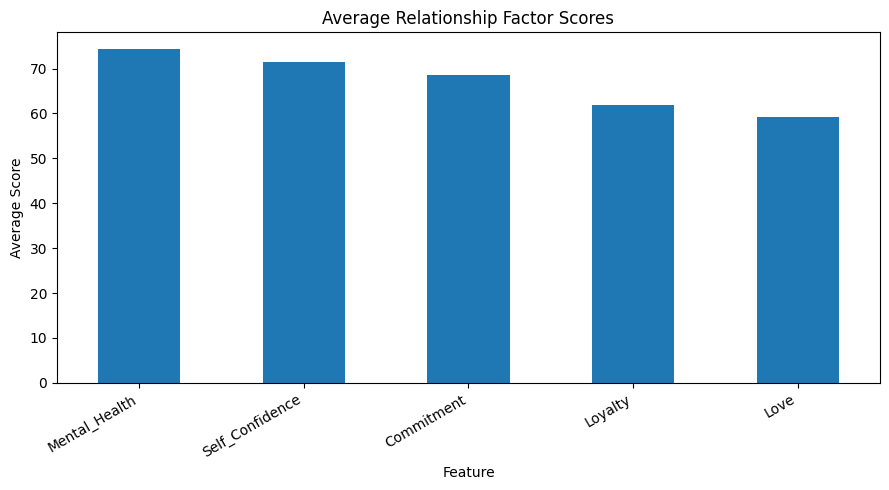

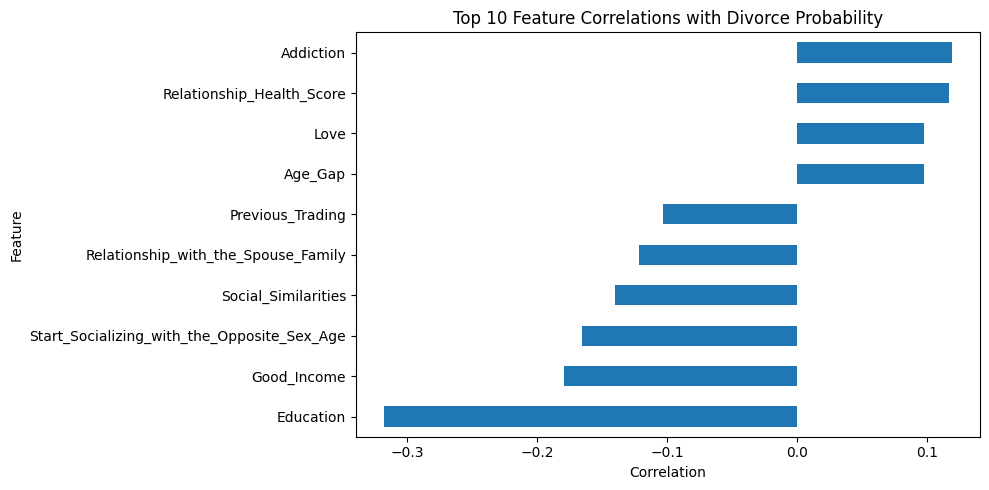

Visualization project completed successfully.
All charts saved inside the 'visuals' folder.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Load dataset
df = pd.read_csv("Marriage_Divorce_DB.csv")

# Clean column names
df.columns = (
    df.columns
    .str.strip()
    .str.replace(" ", "_", regex=False)
    .str.replace("-", "_", regex=False)
    .str.replace("/", "_", regex=False)
)

target = "Divorce_Probability"

# Create risk category
df["Risk_Category"] = pd.cut(
    df[target],
    bins=[-float("inf"), 1.7, 2.3, float("inf")],
    labels=["Low Risk", "Medium Risk", "High Risk"]
)

# Create relationship health score
health_features = [
    "Love",
    "Commitment",
    "Loyalty",
    "Mental_Health",
    "Self_Confidence"
]

df["Relationship_Health_Score"] = df[health_features].mean(axis=1)

# Create output folder
out_dir = Path("visuals")
out_dir.mkdir(exist_ok=True)

# 1. Divorce Probability Distribution
plt.figure(figsize=(8, 5))
plt.hist(df[target], bins=15)
plt.title("Distribution of Divorce Probability")
plt.xlabel("Divorce Probability")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig(out_dir / "01_divorce_probability_distribution.png", dpi=300)
plt.show()

# 2. Risk Category Distribution
risk_counts = df["Risk_Category"].value_counts().reindex(
    ["Low Risk", "Medium Risk", "High Risk"]
)

plt.figure(figsize=(8, 5))
risk_counts.plot(kind="bar")
plt.title("Divorce Risk Category Distribution")
plt.xlabel("Risk Category")
plt.ylabel("Number of Records")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(out_dir / "02_risk_category_distribution.png", dpi=300)
plt.show()

# 3. Average Divorce Probability by Risk Category
avg_risk = df.groupby("Risk_Category", observed=False)[target].mean().reindex(
    ["Low Risk", "Medium Risk", "High Risk"]
)

plt.figure(figsize=(8, 5))
avg_risk.plot(kind="bar")
plt.title("Average Divorce Probability by Risk Category")
plt.xlabel("Risk Category")
plt.ylabel("Average Divorce Probability")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(out_dir / "03_avg_divorce_probability_by_risk.png", dpi=300)
plt.show()

# 4. Relationship Health Score vs Divorce Probability
plt.figure(figsize=(8, 5))
plt.scatter(df["Relationship_Health_Score"], df[target], alpha=0.75)
plt.title("Relationship Health Score vs Divorce Probability")
plt.xlabel("Relationship Health Score")
plt.ylabel("Divorce Probability")
plt.tight_layout()
plt.savefig(out_dir / "04_health_score_vs_divorce_probability.png", dpi=300)
plt.show()

# 5. Love vs Divorce Probability
plt.figure(figsize=(8, 5))
plt.scatter(df["Love"], df[target], alpha=0.75)
plt.title("Love Score vs Divorce Probability")
plt.xlabel("Love")
plt.ylabel("Divorce Probability")
plt.tight_layout()
plt.savefig(out_dir / "05_love_vs_divorce_probability.png", dpi=300)
plt.show()

# 6. Commitment vs Divorce Probability
plt.figure(figsize=(8, 5))
plt.scatter(df["Commitment"], df[target], alpha=0.75)
plt.title("Commitment Score vs Divorce Probability")
plt.xlabel("Commitment")
plt.ylabel("Divorce Probability")
plt.tight_layout()
plt.savefig(out_dir / "06_commitment_vs_divorce_probability.png", dpi=300)
plt.show()

# 7. Average Relationship Factor Scores
emotion_cols = [
    "Love",
    "Commitment",
    "Loyalty",
    "Mental_Health",
    "Self_Confidence"
]

emotion_avg = df[emotion_cols].mean().sort_values(ascending=False)

plt.figure(figsize=(9, 5))
emotion_avg.plot(kind="bar")
plt.title("Average Relationship Factor Scores")
plt.xlabel("Feature")
plt.ylabel("Average Score")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(out_dir / "07_average_relationship_factor_scores.png", dpi=300)
plt.show()

# 8. Top Correlations with Divorce Probability
numeric_df = df.select_dtypes(include="number")

corr = (
    numeric_df
    .corr(numeric_only=True)[target]
    .drop(target)
    .sort_values(key=abs, ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 5))
corr.sort_values().plot(kind="barh")
plt.title("Top 10 Feature Correlations with Divorce Probability")
plt.xlabel("Correlation")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig(out_dir / "08_top_correlations_with_divorce_probability.png", dpi=300)
plt.show()

# Save cleaned dataset
df.to_csv("marriage_divorce_cleaned_for_python.csv", index=False)

print("Visualization project completed successfully.")
print("All charts saved inside the 'visuals' folder.")